In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

## Cleaning and EDA

In [2]:
df = pd.read_csv("data2/numerical_data.csv", index_col=0, parse_dates=True)

In [3]:
df.isna().sum()

Gold              0
DXY               0
Real_Yield_10Y    0
Breakeven_10Y     0
Fed_Funds         0
WTI_Oil           0
SP500             0
VIX               0
CPI_YoY           0
M2_YoY            0
dtype: int64

In [4]:
df["log_price"] = np.log(df["Gold"])
df["t"] = np.arange(len(df))

## Trend Model

In [5]:
forecast_horizon = 325
start_index      = len(df) - forecast_horizon - 1
WINDOW           = 252 * 2
POLY_DEGREE      = 3   # tune: 2 = quadratic, 3 = cubic, etc.


# ── 1. POLYNOMIAL TREND ───────────────────────────────────────────────────────
def fit_polynomial_trend(train_data, deg=POLY_DEGREE):
    """
    Fit a degree-`deg` polynomial of t to log_price using LinearRegression.
    Adding t^2, t^3 … as explicit columns keeps the sklearn interface intact,
    making forecast_next_day straightforward.
    """
    train_data = train_data.copy()
    t = train_data["t"].values

    # Build polynomial feature matrix  [t, t^2, t^3, …]
    poly_cols = {f"t_{i}": t ** i for i in range(1, deg + 1)}
    X_trend   = pd.DataFrame(poly_cols, index=train_data.index)
    y_trend   = train_data["log_price"]

    trend_model = LinearRegression()
    trend_model.fit(X_trend, y_trend)

    train_data["trend"]    = trend_model.predict(X_trend)
    train_data["residual"] = train_data["log_price"] - train_data["trend"]

    return trend_model, train_data, deg


# ── 2. NEXT-DAY FORECAST ──────────────────────────────────────────────────────
def forecast_next_day(trend_model, last_t, deg=POLY_DEGREE):
    """Forecast next day's gold price from the polynomial trend alone."""
    next_t     = last_t + 1
    poly_cols  = {f"t_{i}": [next_t ** i] for i in range(1, deg + 1)}
    X_next     = pd.DataFrame(poly_cols)
    trend_fore = trend_model.predict(X_next)[0]
    return np.exp(trend_fore)


# ── 3. ROLLING FORECAST LOOP ──────────────────────────────────────────────────
def run_rolling_forecast(df, start_index, window=WINDOW, deg=POLY_DEGREE):
    """
    Rolling window forecast — fits a fresh polynomial trend at every step.

    Returns
    -------
    dates, predictions, actuals
    """
    predictions, actuals, dates = [], [], []
    total = len(df) - start_index - 1

    for i in range(start_index, len(df) - 1):
        pct = (i - start_index + 1) / total * 100
        print(f"\rProgress: {pct:.2f}%", end="")

        train_data = df.iloc[max(0, i - window + 1): i + 1].copy()

        trend_model, train_data, deg_ = fit_polynomial_trend(train_data, deg=deg)

        price_forecast = forecast_next_day(
            trend_model, train_data["t"].iloc[-1], deg=deg_
        )

        predictions.append(price_forecast)
        actuals.append(df["Gold"].iloc[i + 1])
        dates.append(df.index[i + 1])

    print("\nDone!")
    return dates, predictions, actuals

# ── 5. RUN ────────────────────────────────────────────────────────────────────
dates, predictions, actuals = run_rolling_forecast(df, start_index)

Progress: 100.00%
Done!


In [6]:
results = pd.DataFrame({
    "Date": dates,
    "Actual": actuals,
    "Predicted": predictions
}).set_index("Date")

In [7]:
results_2025 = results[results.index.year == 2025]
mape_2025 = (np.abs((results_2025["Actual"] - results_2025["Predicted"]) / results_2025["Actual"]).mean()) * 100
print(f"MAPE 2025: {mape_2025:.4f}%")

MAPE 2025: 3.0798%


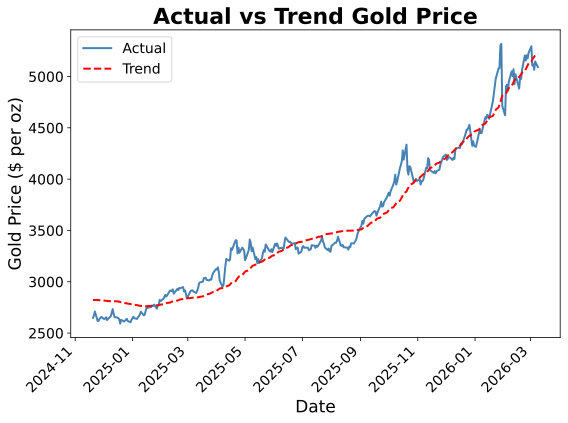

In [19]:
results_last_month = results.iloc[:]

plt.figure(figsize=(8, 6))
plt.plot(results_last_month.index, results_last_month["Actual"], color="steelblue", linewidth=2, label="Actual")
plt.plot(results_last_month.index, results_last_month["Predicted"], color="red", linewidth=2, linestyle="--", label="Trend")
plt.title("Actual vs Trend Gold Price", fontsize=22, fontweight="bold")
plt.xlabel("Date", fontsize=17)
plt.ylabel("Gold Price ($ per oz)", fontsize=17)
plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("results/p1_last_month_forecast_trend.png", bbox_inches="tight")
plt.show()

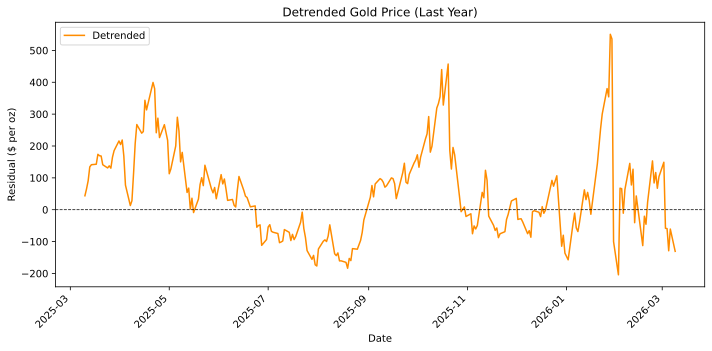

In [17]:
results_last_year = results.iloc[-252:]

detrended = results_last_year["Actual"] - results_last_year["Predicted"]

plt.figure(figsize=(10, 5))
plt.plot(results_last_year.index, detrended,
         color="darkorange", linewidth=1.5, label="Detrended")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Detrended Gold Price (Last Year)")
plt.xlabel("Date")
plt.ylabel("Residual ($ per oz)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("results/p1_detrended_gold_last_year.png", bbox_inches="tight")
plt.show()